In [37]:
from tensorflow.keras.models import load_model

model = load_model("model\emotion_model.h5")
model.summary()

<>:3: SyntaxWarning: invalid escape sequence '\e'
<>:3: SyntaxWarning: invalid escape sequence '\e'
C:\Users\elsen\AppData\Local\Temp\ipykernel_11640\966434472.py:3: SyntaxWarning: invalid escape sequence '\e'
  model = load_model("model\emotion_model.h5")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 7,452,103 (28.43 MB)

 Trainable params: 7,445,701 (28.40 MB)

 Non-trainable params: 6,400 (25.00 KB)

 Optimizer params: 2 (12.00 B)

In [ ]:
import os

import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
)
from tensorflow.keras.models import load_model

import kagglehub

dataset_path = kagglehub.dataset_download(
    "samithsachidanandan/human-face-emotions"
)

MODEL_PATH = "model\\emotion_model.h5"
DATASET_DIR = os.path.join(dataset_path, "Data")
BATCH_SIZE = 64
IMG_SIZE = (48, 48)
EPOCHS = 50
FINE_TUNE_LAST_LAYERS = 20
AUTOTUNE = tf.data.AUTOTUNE

model = load_model(MODEL_PATH)

fine_tune_at = max(len(model.layers) - FINE_TUNE_LAST_LAYERS, 0)
for index, layer in enumerate(model.layers):
    layer.trainable = index >= fine_tune_at
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    label_mode="int",
)

class_names = train_ds.class_names
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255.0)

train_ds = train_ds.map(lambda images, labels: (normalization_layer(images), labels))
val_ds = val_ds.map(lambda images, labels: (normalization_layer(images), labels))

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

train_labels = np.concatenate([labels.numpy() for _, labels in train_ds.unbatch().batch(4096)], axis=0)
class_ids = np.unique(train_labels)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=train_labels,
)
class_weights = dict(zip(class_ids, class_weights_array))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

Found 59099 files belonging to 5 classes.
Using 47280 files for training.
Found 59099 files belonging to 5 classes.
Using 11819 files for validation.


In [24]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/50


739/739 ━━━━━━━━━━━━━━━━━━━━ 1326s 2s/step - accuracy: 0.3903 - loss: 1.7794 - val_accuracy: 0.4203 - val_loss: 1.3480
Epoch 2/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 1491s 2s/step - accuracy: 0.4559 - loss: 1.3449 - val_accuracy: 0.4923 - val_loss: 1.2192
Epoch 3/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 1542s 2s/step - accuracy: 0.5030 - loss: 1.2468 - val_accuracy: 0.5364 - val_loss: 1.1377
Epoch 4/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 1471s 2s/step - accuracy: 0.5239 - loss: 1.1962 - val_accuracy: 0.5581 - val_loss: 1.0929
Epoch 5/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 1494s 2s/step - accuracy: 0.5404 - loss: 1.1601 - val_accuracy: 0.5726 - val_loss: 1.0532
Epoch 6/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 1283s 2s/step - accuracy: 0.5589 - loss: 1.1265 - val_accuracy: 0.5862 - val_loss: 1.0308
Epoch 7/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 1314s 2s/step - accuracy: 0.5680 - loss: 1.1049 - val_accuracy: 0.5962 - val_loss: 1.0048
Epoch 8/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 1232s 2s/step - accuracy: 0.5788 - loss: 1.0848 - val_accurac

In [ ]:
save_path = "emotion_model_finetuned.h5"
weights_path = "emotion_model_finetuned.weights.h5"

try:
    model.save(save_path)
    print(f"Saved fine-tuned model to {save_path}")
except Exception as error:
    print(f"Full model save failed: {error}")
    model.save_weights(weights_path)
    print(f"Saved model weights to {weights_path}")

Full model save failed: cannot pickle 'module' object
Saved model weights to emotion_model_finetuned.weights.h5


Precision (weighted): 0.7004
Recall (weighted): 0.6941
F1-Score (weighted): 0.6931

Classification Report:

              precision    recall  f1-score   support

       Angry       0.55      0.71      0.62      2031
        Fear       0.56      0.42      0.48      1982
       Happy       0.91      0.84      0.87      3722
         Sad       0.61      0.60      0.61      2441
     Suprise       0.71      0.81      0.75      1643

    accuracy                           0.69     11819
   macro avg       0.67      0.68      0.67     11819
weighted avg       0.70      0.69      0.69     11819



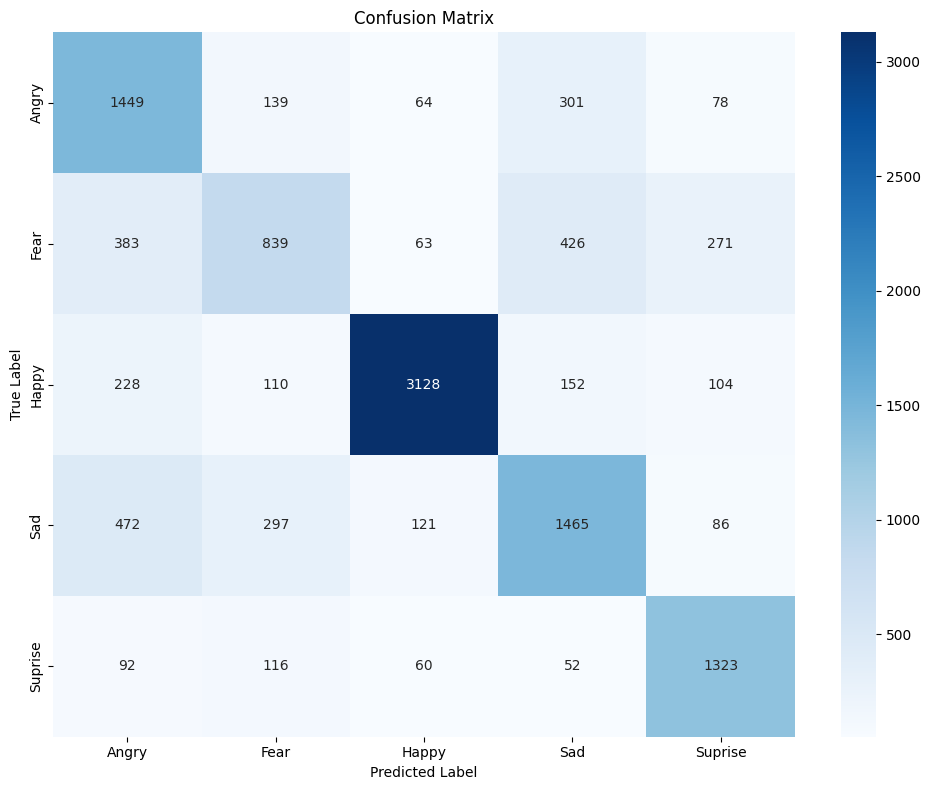

In [40]:
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Load the fine-tuned model directly from disk for evaluation.
eval_model = load_model("emotion_model_finetuned.keras")

# Collect ground-truth labels from the validation dataset
true_labels = np.concatenate([batch_labels.numpy() for _, batch_labels in val_ds], axis=0)

# Predict class probabilities and convert them to class indices
predicted_probs = eval_model.predict(val_ds, verbose=0)
predicted_labels = np.argmax(predicted_probs, axis=1)

# Core metrics
precision = precision_score(true_labels, predicted_labels, average="weighted", zero_division=0)
recall = recall_score(true_labels, predicted_labels, average="weighted", zero_division=0)
f1 = f1_score(true_labels, predicted_labels, average="weighted", zero_division=0)
cm = confusion_matrix(true_labels, predicted_labels)
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    zero_division=0,
)

print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")
print("\nClassification Report:\n")
print(report)

# Confusion matrix visualization
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()